# Descubrimiento de tópicos

Los objetivos de este cuaderno son: extraer un corpus representativo y sin sesgos de prospectos médicos desde la API oficial de CIMA (AEMPS); determinar matemáticamente el número óptimo de secciones (tópicos) en los que se divide un prospecto; y aplicar triangulación metodológica comparando tres enfoques de *Machine Learning*: Probabilístico (LDA), Algebraico (NMF) y Semántico (Embeddings + K-Means) para descubrir la estructura latente de la información.

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import time
import re
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer

### 1. Construcción del Corpus: Minería de Datos y Muestreo Estratégico
Para garantizar que el modelo sea robusto y generalizable, no podemos extraer prospectos de forma secuencial (alfabética). En esta sección se implementa un *scraper* que consulta la API REST de CIMA utilizando un **muestreo estratificado por Grupos ATC (Clasificación Anatómica)**. Esto asegura una distribución equitativa de familias de fármacos (digestivos, cardiovasculares, neurológicos, etc.) y de formas farmacéuticas. Además, se realiza una segmentación lógica inicial basándose en el HTML original.

In [1]:
class CimaScraperInfinito:
    def __init__(self):
        self.base_url = "https://cima.aemps.es/cima/rest"
        # Filtros de texto
        self.patron_titulo_num = re.compile(r'^\d+\.\s+')
        self.titulos_oficiales = [
            "qué es", "antes de tomar", "cómo tomar", "posibles efectos", 
            "conservación", "contenido del envase", "información adicional"
        ]
        # Todos los grupos ATC Nivel 1
        self.grupos_atc = list("ABCDGHJLMNPRSV")

    # Devuelve True si es un título de sección
    def es_titulo(self, texto, tag_name):
        texto_lower = texto.lower().strip()
        if tag_name in ['h1']: return True
        if self.patron_titulo_num.match(texto) and len(texto) < 100: return True
        if len(texto) < 60 and any(oficial in texto_lower for oficial in self.titulos_oficiales): return True
        return False

    def limpiar_texto(self, texto):
        texto = texto.replace('\xa0', ' ').replace('\r', '').replace('\n', ' ')
        return re.sub(r'\s+', ' ', texto).strip()

    def procesar_prospecto(self, url_html, nregistro, nombre_med):
        try:
            r = requests.get(url_html, timeout=10)
            if r.status_code != 200: return []
            
            soup = BeautifulSoup(r.content, 'html.parser')
            filas = []
            seccion_actual = "Introducción / Sin Título"
            buffer_parrafo = ""
            
            # Encontramos las frases del prospecto del código html
            elementos = soup.find_all(['h1', 'h2', 'h3', 'h4', 'p', 'li', 'div'])
            
            for elem in elementos:
                if elem.name == 'div' and elem.find(['p', 'h1', 'h2']): continue 
                
                texto_raw = elem.get_text(strip=True)
                texto_limpio = self.limpiar_texto(texto_raw)
                if not texto_limpio: continue

                if self.es_titulo(texto_limpio, elem.name):
                    if buffer_parrafo:
                        filas.append({
                            'ID_Prospecto': nregistro,
                            'Medicamento': nombre_med,
                            'Titulo_Seccion': seccion_actual,
                            'Parrafo': buffer_parrafo
                        })
                        buffer_parrafo = ""
                    seccion_actual = texto_limpio
                else:
                    sep = " " if buffer_parrafo else ""
                    buffer_parrafo += sep + texto_limpio
                    if texto_limpio.endswith(('.', '?', '!')):
                        if len(buffer_parrafo) > 15:
                            filas.append({
                                'ID_Prospecto': nregistro,
                                'Medicamento': nombre_med,
                                'Titulo_Seccion': seccion_actual,
                                'Parrafo': buffer_parrafo
                            })
                        buffer_parrafo = ""
            
            if buffer_parrafo and len(buffer_parrafo) > 15:
                filas.append({
                    'ID_Prospecto': nregistro,
                    'Medicamento': nombre_med,
                    'Titulo_Seccion': seccion_actual,
                    'Parrafo': buffer_parrafo
                })
                
            return filas
        except Exception:
            return []

    def obtener_dataset_equilibrado(self, objetivo_total=2000):
        datos_totales = []
        ids_procesados = set()
        nombres_raiz_vistos = set()

        num_grupos = len(self.grupos_atc)
        objetivo_por_grupo = int(objetivo_total / num_grupos) + 5 
        
        print(f"   Objetivo Total: {objetivo_total}")
        print(f"   Objetivo por Grupo ATC: ~{objetivo_por_grupo} prospectos/grupo")

        
        for atc in self.grupos_atc:
            # Reseteo de contadores para el nuevo grupo
            candidatos_grupo = 0
            pagina = 1
            fin_grupo = False
            
            print(f"--- Explorando GRUPO TERAPÉUTICO '{atc}' ---")
            
            while candidatos_grupo < objetivo_por_grupo and not fin_grupo:
                try:
                    # Paginación
                    params = {'atc': atc, 'tamanioPagina': 100, 'pagina': pagina} 
                    r = requests.get(f"{self.base_url}/medicamentos", params=params, timeout=10)
                    if r.status_code != 200: 
                        print(f"   (Fallo red pág {pagina})", end=" ")
                        time.sleep(1)
                        continue
                        
                    data = r.json()
                    resultados = data.get('resultados', [])
                except:
                    print("Error API")
                    break
                
                if not resultados:
                    fin_grupo = True # Se acabaron los medicamentos de este grupo
                    break
                
                # Procesar resultados de la página
                nuevos_en_pag = 0
                for med in resultados:
                    if candidatos_grupo >= objetivo_por_grupo: break
                    
                    nombre = med['nombre']
                    nregistro = med['nregistro']
                    
                    # Compruebo si no lo he cogido ya
                    try:
                        raiz_nombre = nombre.split()[0].split('/')[0].lower()
                        if len(raiz_nombre) < 3: raiz_nombre = nombre.lower()
                    except:
                        raiz_nombre = nombre.lower()

                    if raiz_nombre in nombres_raiz_vistos: continue
                    
                    # Encontrar html
                    url_html = None
                    if med.get('docs'):
                        for doc in med['docs']:
                            if doc.get('tipo') == 2:
                                possible_url = doc.get('urlHtml')
                                if possible_url:
                                    url_html = possible_url
                                    break
                    
                    if url_html:
                        nuevas_filas = self.procesar_prospecto(url_html, nregistro, nombre)
                        if nuevas_filas:
                            datos_totales.extend(nuevas_filas)
                            ids_procesados.add(nregistro)
                            nombres_raiz_vistos.add(raiz_nombre)
                            
                            candidatos_grupo += 1
                            nuevos_en_pag += 1
                            sys.stdout.write(".") 
                            sys.stdout.flush()
                        
                        time.sleep(0.05)
                
                print(f" Pág {pagina} OK ({candidatos_grupo}/{objetivo_por_grupo})")
                pagina += 1

        return pd.DataFrame(datos_totales)

In [5]:
scraper = CimaScraperInfinito()

df_dataset = scraper.obtener_dataset_equilibrado(objetivo_total=2000)

if not df_dataset.empty:
    nombre_fichero = "dataset_prospectos_final_2000.xlsx"
    df_dataset.to_excel(nombre_fichero, index=False)
    print(f"\n Guardado en: {nombre_fichero}")
    print(f"   Total de párrafos: {len(df_dataset)}")
    print(f"   Total de prospectos: {df_dataset['ID_Prospecto'].nunique()}")
else:
    print("Error: No se obtuvieron datos.")

   Objetivo Total: 2000
   Objetivo por Grupo ATC: ~147 prospectos/grupo
--- Explorando GRUPO TERAPÉUTICO 'A' ---
................................................................................ Pág 1 OK (80/147)
.............................. Pág 2 OK (110/147)
..................................... Pág 3 OK (147/147)
--- Explorando GRUPO TERAPÉUTICO 'B' ---
. Pág 1 OK (1/147)
................................................... Pág 2 OK (52/147)
.................................................................... Pág 3 OK (120/147)
........................... Pág 4 OK (147/147)
--- Explorando GRUPO TERAPÉUTICO 'C' ---
 Pág 1 OK (0/147)
 Pág 2 OK (0/147)
................. Pág 3 OK (17/147)
............................... Pág 4 OK (48/147)
......................................................... Pág 5 OK (105/147)
.......................................... Pág 6 OK (147/147)
--- Explorando GRUPO TERAPÉUTICO 'D' ---
 Pág 1 OK (0/147)
... Pág 2 OK (3/147)
...... Pág 3 OK (9/147)
.........

### 2. Análisis del Número Óptimo de Tópicos (k)

El prospecto estándar europeo se divide en 6 secciones burocráticas. Nuestra hipótesis es que la información real está más fragmentada. Para descubrir el número real de dimensiones informativas (k), evaluamos el corpus iterando desde k=6 hasta k=20 utilizando tres métricas estadísticas de validación cruzada:

* **Perplejidad (LDA):** Mide la capacidad de generalización del modelo probabilístico (buscamos minimización).
* **Inercia / Método del Codo (K-Means):** Evalúa la varianza intra-cluster (buscamos el punto de inflexión).
* **Silhouette Score (K-Means):** Cuantifica la cohesión y separación de los clusters en el espacio vectorial denso (buscamos maximización).

Analizando la estructura latente de 192822 párrafos...
Vectorizando para LDA...
Calculando Embeddings...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]


Iniciando búsqueda del número óptimo de temas (k)...
   Probando con k=6 temas...
   Probando con k=7 temas...
   Probando con k=8 temas...
   Probando con k=9 temas...
   Probando con k=10 temas...
   Probando con k=11 temas...
   Probando con k=12 temas...
   Probando con k=13 temas...
   Probando con k=14 temas...
   Probando con k=15 temas...
   Probando con k=16 temas...
   Probando con k=17 temas...
   Probando con k=18 temas...
   Probando con k=19 temas...
   Probando con k=20 temas...


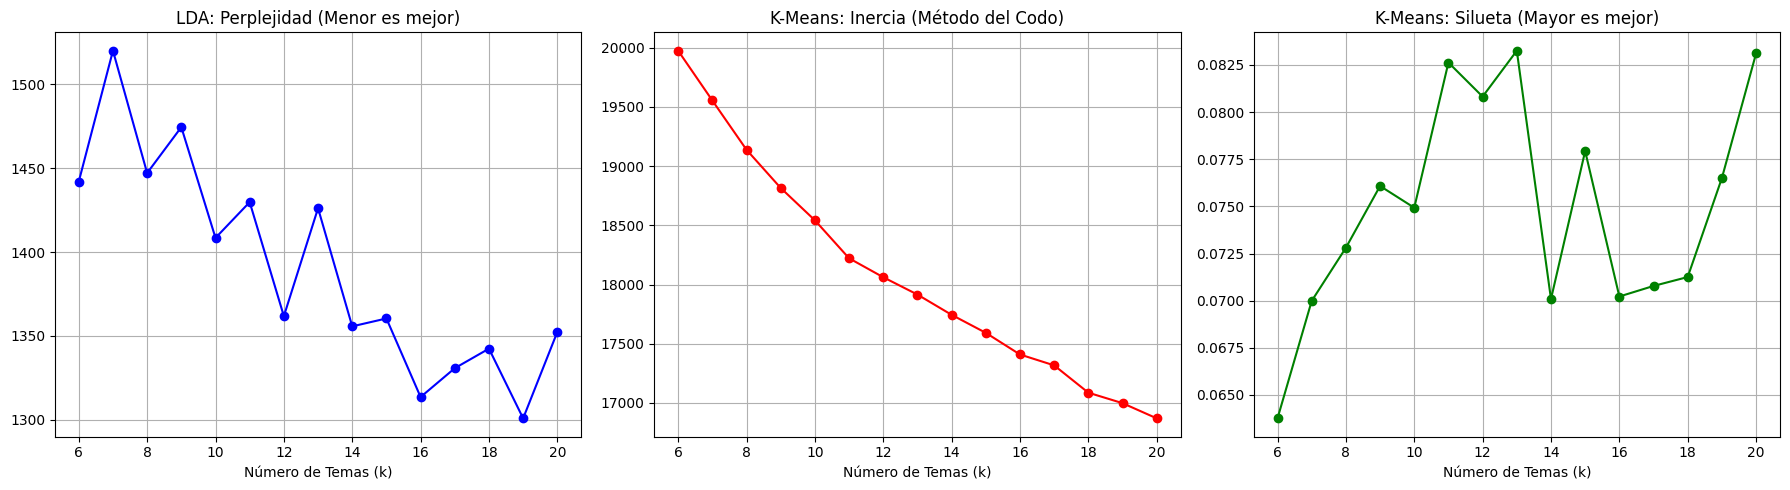


ANÁLISIS DE RESULTADOS:
1. LDA Perplejidad: Busca el punto más bajo.
2. K-Means Codo (Roja): Busca dónde la curva hace un ángulo (el codo).
3. K-Means Silueta (Verde): Busca el pico más alto.


In [ ]:
# Cargamos los datos
archivo = "/kaggle/input/tfg-dataset2000/dataset_prospectos_final_2000.xlsx" 
df = pd.read_excel(archivo)
df = df.dropna(subset=['Parrafo'])
textos = df['Parrafo'].astype(str).tolist()

print(f"Analizando la estructura latente de {len(textos)} párrafos...")

# Preparación de LDA y K-Means

# LDA (Bag of Words)
print("Vectorizando para LDA...")
stopwords_es = list({
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 'para', 
    'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o', 
    'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 'también',
    'me', 'hasta', 'desde', 'nos', 'durante', 'uno', 'ni', 'contra', 'ese', 'eso', 'mí',
    'medicamento', 'prospecto', 'puede', 'consulte', 'medico', 'farmaceutico', 'tratamiento'
})
tf_vectorizer = CountVectorizer(max_df=0.95, min_df=5, stop_words=stopwords_es)
tf = tf_vectorizer.fit_transform(textos)

# Clustering Semántico (Embeddings)
print("Calculando Embeddings...")
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')
embeddings = model.encode(textos, show_progress_bar=True)

# Búsqueda de K óptimo
k_values = range(6, 21, 1) 
lda_perplexities = []
kmeans_inertias = []
kmeans_silhouettes = []

print("\nIniciando búsqueda del número óptimo de temas (k)...")

for k in k_values:
    print(f"   Probando con k={k} temas...")
    
    # 1. Evaluar LDA (Perplejidad)
    lda = LatentDirichletAllocation(n_components=k, learning_method='online', random_state=42)
    lda.fit(tf)
    lda_perplexities.append(lda.perplexity(tf))
    
    # 2. Evaluar K-Means (Inercia y Silueta)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans.fit(embeddings)
    kmeans_inertias.append(kmeans.inertia_)
    # Silhouette Score
    sil = silhouette_score(embeddings, kmeans.labels_, sample_size=2000)
    kmeans_silhouettes.append(sil)

# Gráficas y resultados
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: LDA Perplejidad
ax1.plot(k_values, lda_perplexities, 'bo-')
ax1.set_title("LDA: Perplejidad (Menor es mejor)")
ax1.set_xlabel("Número de Temas (k)")
ax1.grid(True)

# Gráfica 2: K-Means Inercia (Método del Codo)
ax2.plot(k_values, kmeans_inertias, 'ro-')
ax2.set_title("K-Means: Inercia (Método del Codo)")
ax2.set_xlabel("Número de Temas (k)")
ax2.grid(True)


# Gráfica 3: K-Means Silueta (Calidad de Separación)
ax3.plot(k_values, kmeans_silhouettes, 'go-')
ax3.set_title("K-Means: Silueta (Mayor es mejor)")
ax3.set_xlabel("Número de Temas (k)")
ax3.grid(True)

plt.tight_layout()
plt.savefig("justificacion_numero_temas.png")
plt.show()

print("\nANÁLISIS DE RESULTADOS:")
print("1. LDA Perplejidad: Busca el punto más bajo.")
print("2. K-Means Codo (Roja): Busca dónde la curva hace un ángulo (el codo).")
print("3. K-Means Silueta (Verde): Busca el pico más alto.")

### 3. Triangulación Metodológica
Con el valor de k definido, procedemos a ejecutar tres algoritmos de naturaleza matemática opuesta. Si los tres métodos coinciden en aislar una temática (ej. Embarazo), la evidencia de su existencia estructural será concluyente.

#### 3.1. Preparación Léxica y Modelo Probabilístico: Latent Dirichlet Allocation (LDA)
Se aplica un preprocesamiento del texto (limpieza de puntuación y *stopwords* específicas del dominio médico). Posteriormente, se genera una matriz de frecuencias puras (*Bag of Words*) para alimentar el modelo LDA, el cual asume que cada párrafo es una distribución probabilística de tópicos latentes.

In [ ]:
# Cargamos los datos
archivo = "/kaggle/input/tfg-dataset2000/dataset_prospectos_final_2000.xlsx" 
df = pd.read_excel(archivo)

# Trabajamos con párrafos que tengan texto
df = df.dropna(subset=['Parrafo']).reset_index(drop=True)

# Resultado de los gráficos
NUM_TOPICS = 11

print(f" Analizando {len(df)} párrafos con 3 métodos diferentes...")

# Preprocesamiento para LDA/NMF (Bag of Words) 
stopwords_es = {
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 'para', 
    'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o', 
    'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 'también',
    'me', 'hasta', 'desde', 'nos', 'durante', 'uno', 'ni', 'contra', 'ese', 'eso', 'mí',
    'tengo', 'ha', 'hay', 'sus', 'tu', 'tus', 'te', 'ti', 'si', 'medicamento', 'prospecto',
    'puede', 'consulte', 'medico', 'farmaceutico', 'tratamiento', 'debe', 'pueden', 'uso', 'médico', 'farmacéutico'
} 

def limpiar_texto(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) # Quitar signos de puntuación
    return text

df['texto_limpio'] = df['Parrafo'].apply(limpiar_texto)

# Vectorización (Convertir texto a matriz de conteo)
print("1️ Preparando matrices para LDA y NMF...")
# Para LDA usamos conteo simple (frecuencia)
tf_vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words=list(stopwords_es))
tf = tf_vectorizer.fit_transform(df['texto_limpio'])

# Para NMF usamos TF-IDF (importancia relativa)
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words=list(stopwords_es))
tfidf = tfidf_vectorizer.fit_transform(df['texto_limpio'])

feature_names = tf_vectorizer.get_feature_names_out()


# LDA (Probabilístico)
print(f" Ejecutando LDA ({NUM_TOPICS} temas)...")
lda = LatentDirichletAllocation(n_components=NUM_TOPICS, max_iter=10, learning_method='online', random_state=42)
lda_output = lda.fit_transform(tf)
df['LDA_Topic_ID'] = np.argmax(lda_output, axis=1)



2026-02-01 17:17:56.888365: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769966277.329354      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769966277.459821      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769966278.582534      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769966278.582582      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769966278.582584      55 computation_placer.cc:177] computation placer alr

 Analizando 192822 párrafos con 3 métodos diferentes...
1️ Preparando matrices para LDA y NMF...
 Ejecutando LDA (11 temas)...


#### 3.2. Modelo Algebraico: Non-Negative Matrix Factorization (NMF)

A diferencia de LDA, NMF es un método determinista basado en álgebra lineal. Se alimenta de una matriz **TF-IDF** (Term Frequency - Inverse Document Frequency) para penalizar las palabras genéricas y dar más peso a la terminología clínica específica. 

In [ ]:
# NMF (Algebraico)
print(f" Ejecutando NMF ({NUM_TOPICS} temas)...")
nmf = NMF(n_components=NUM_TOPICS, random_state=42, init='nndsvd')
nmf_output = nmf.fit_transform(tfidf)
df['NMF_Topic_ID'] = np.argmax(nmf_output, axis=1)



 Ejecutando NMF (11 temas)...


#### 3.3. Modelo Lingüístico Profundo: Clustering Semántico (Embeddings densos)

Los modelos anteriores (LDA y NMF) sufren ante la sinonimia ("cefalea" y "dolor de cabeza" son entidades distintas para ellos). Para solucionarlo, empleamos un modelo *Transformer* preentrenado (`paraphrase-multilingual-mpnet-base-v2`) que proyecta los párrafos en un espacio vectorial denso de 768 dimensiones. Agrupamos estos vectores mediante el algoritmo K-Means, logrando que la separación se base en la intención semántica y no en la literalidad léxica.

In [ ]:
#CLUSTERING SEMÁNTICO (Embeddings)
print(f" Ejecutando Clustering Semántico (MPNet + KMeans)...")
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')
embeddings = model.encode(df['Parrafo'].astype(str).tolist(), show_progress_bar=False)
kmeans = KMeans(n_clusters=NUM_TOPICS, random_state=42, n_init=10)
df['Cluster_Semantico_ID'] = kmeans.fit_predict(embeddings)



 Ejecutando Clustering Semántico (MPNet + KMeans)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### 4. Interpretación de Resultados y Alineación

Una vez entrenados los modelos, extraemos las palabras con mayor peso (*Top Features*) para cada uno de los tópicos descubiertos. Esto nos permitirá realizar un análisis cualitativo y asignar una "Pregunta Universal" humana a cada etiqueta numérica generada.

In [ ]:
# Resultados
def mostrar_top_palabras(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        topics[topic_idx] = ", ".join(top_features)
    return topics


# Diccionarios de palabras clave
keywords_lda = mostrar_top_palabras(lda, feature_names, 8)
keywords_nmf = mostrar_top_palabras(nmf, feature_names, 8)

resumen_temas = []
for i in range(NUM_TOPICS):
    # Ejemplo representativo del Cluster Semántico (el más cercano al centro)
    ejemplo_semantico = df[df['Cluster_Semantico_ID'] == i]['Parrafo'].iloc[0][:100] + "..." if len(df[df['Cluster_Semantico_ID'] == i]) > 0 else "Sin datos"
    
    resumen_temas.append({
        'Tema_ID': i,
        'LDA_Palabras_Clave': keywords_lda[i],
        'NMF_Palabras_Clave': keywords_nmf[i],
        'Cluster_Semantico_Ejemplo': ejemplo_semantico
    })

df_resumen = pd.DataFrame(resumen_temas)
print(df_resumen.to_string(index=False))

 Tema_ID                                                          LDA_Palabras_Clave                                                              NMF_Palabras_Clave                                                                               Cluster_Semantico_Ejemplo
       0                    después, día, es, dosis, fecha, caducidad, días, utilice adversos, efectos, trata, aparecen, experimenta, incluso, comunicación, sección Prospecto: información para el usuario A.A.S. 100 mg comprimidos Ácido acetilsalicílico Lea todo el ...
       1 niños, medicamentos, deben, cómo, envases, necesita, adolescentes, pregunte             duda, tiene, alguna, otra, pregunte, cualquier, enfermero, producto Si ha padecido mastocitosis (generalmente caracterizada por urticaria) ya que pueden aparecer reacci...
       2       está, usted, embarazada, embarazo, lactancia, utilizar, podría, tiene             niños, alcance, vista, fuera, mantener, adolescentes, menores, años Este medicamento se le ha re

In [ ]:
# Exportamos todo
df.to_excel("TFG_Comparativa_Modelos_Temas.xlsx", index=False)
df_resumen.to_excel("TFG_Leyenda_Temas.xlsx", index=False)